In [162]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [163]:
# Load data
df = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-data-m2.csv')
df.head(3)

,x1,x2
0,-2.694898,-1.591274
1,-1.280104,2.124625
2,3.163615,1.798130


In [164]:
#Checking
display(df.isnull().sum())

,0
x1,0
x2,0


In [165]:
# Scale
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

In [166]:
# PCA 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaled)

results = {}

In [167]:
X_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
display(X_pca.head())

,PCA1,PCA2
0,-0.487221,-0.146081
1,-0.046312,0.272625
2,0.229168,0.014293
3,0.333676,0.108745
4,0.331370,-0.004339


In [168]:
# KMeans
best_k = None
best_score = -1
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=101)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    if score > best_score:
        best_score = score
        best_k = k
results["KMeans"] = (best_k, best_score)

In [169]:
# Hierarchical
best_k_h = None
best_score_h = -1
for k in range(2,9):
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    if score > best_score_h:
        best_score_h = score
        best_k_h = k
results["Hierarchical"] = (best_k_h, best_score_h)

In [170]:
# GMM
best_k_g = None
best_score_g = -1
for k in range(2,9):
    gmm = GaussianMixture(n_components=k, random_state=101)
    labels = gmm.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    if score > best_score_g:
        best_score_g = score
        best_k_g = k
results["GMM"] = (best_k_g, best_score_g)

In [171]:
# Spectral
best_k_s = None
best_score_s = -1
for k in range(2,9):
    sc = SpectralClustering(n_clusters=k, random_state=101, affinity='nearest_neighbors')
    labels = sc.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    if score > best_score_s:
        best_score_s = score
        best_k_s = k
results["Spectral"] = (best_k_s, best_score_s)

In [172]:
results

{'KMeans': (4, np.float64(0.4069249061478638)),
 'Hierarchical': (5, np.float64(0.3798559275241364)),
 'GMM': (4, np.float64(0.40038958758468096)),
 'Spectral': (4, np.float64(0.39078329147405905))}

In [173]:
# Train best model
kmeans = KMeans(n_clusters=2, random_state=101)
labels = kmeans.fit_predict(X_pca)

In [174]:
# Answer to Question #3
print("Cluster of index 500:", labels[500])

Cluster of index 500: 1


In [175]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
#KM2
kmeans_n2 = KMeans(n_clusters=2, random_state=101)
labels_kmeans_n2 = kmeans_n2.fit_predict(X_pca)

In [177]:
#H
hierarchical_n2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_hierarchical_n2 = hierarchical_n2.fit_predict(X_pca)

In [178]:
#GMM
gmm_n2 = GaussianMixture(n_components=4, random_state=101)
labels_gmm_n2 = gmm_n2.fit_predict(X_pca)

In [179]:
#S
spectral_n2 = SpectralClustering(n_clusters=4, random_state=101, affinity='nearest_neighbors')
labels_spectral_n2 = spectral_n2.fit_predict(X_pca)

In [180]:
#KM4
kmeans_n4 = KMeans(n_clusters=4, random_state=101)
labels_kmeans_n4 = kmeans_n4.fit_predict(X_pca)

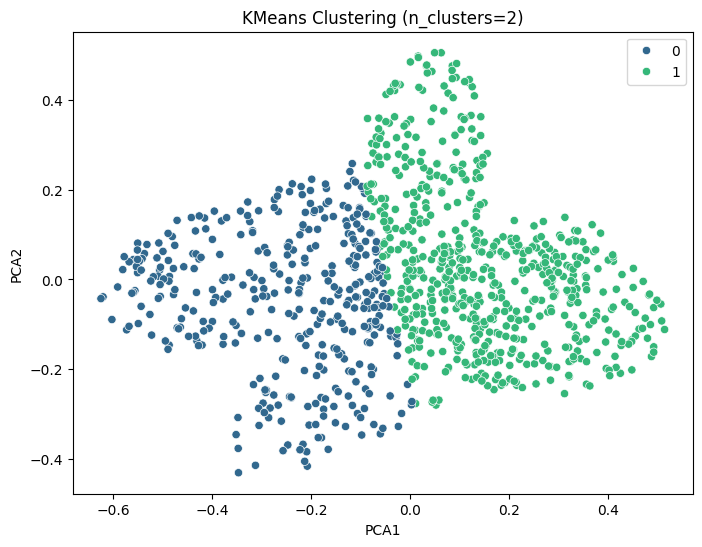

In [181]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca['PCA1'], y=X_pca['PCA2'], hue=labels_kmeans_n2, palette='viridis', legend='full')
plt.title('KMeans Clustering (n_clusters=2)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

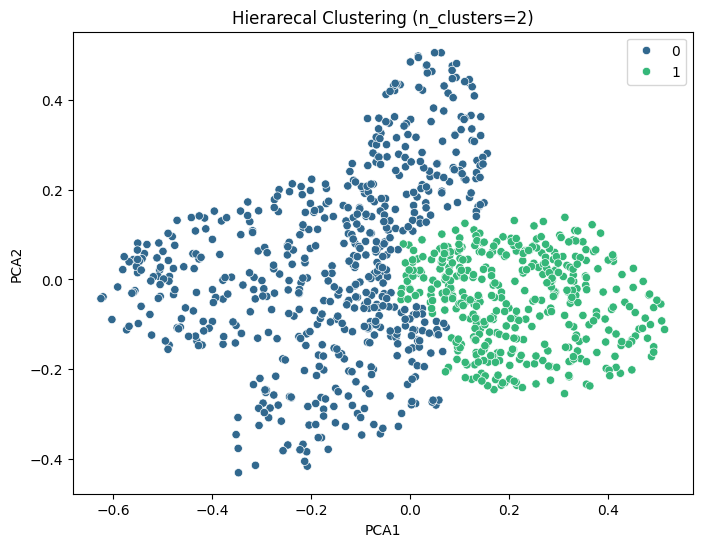

In [182]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca['PCA1'], y=X_pca['PCA2'], hue=labels_hierarchical_n2, palette='viridis', legend='full')
plt.title('Hierarecal Clustering (n_clusters=2)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

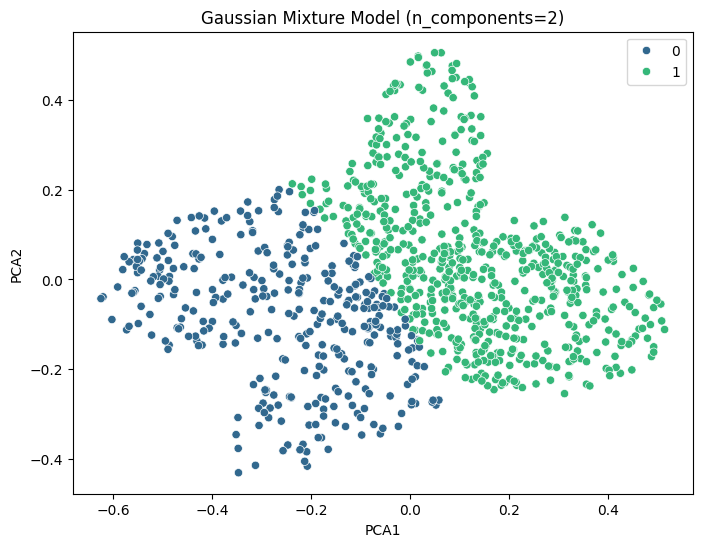

In [183]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca['PCA1'], y=X_pca['PCA2'], hue=labels_gmm_n2, palette='viridis', legend='full')
plt.title('Gaussian Mixture Model (n_components=2)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

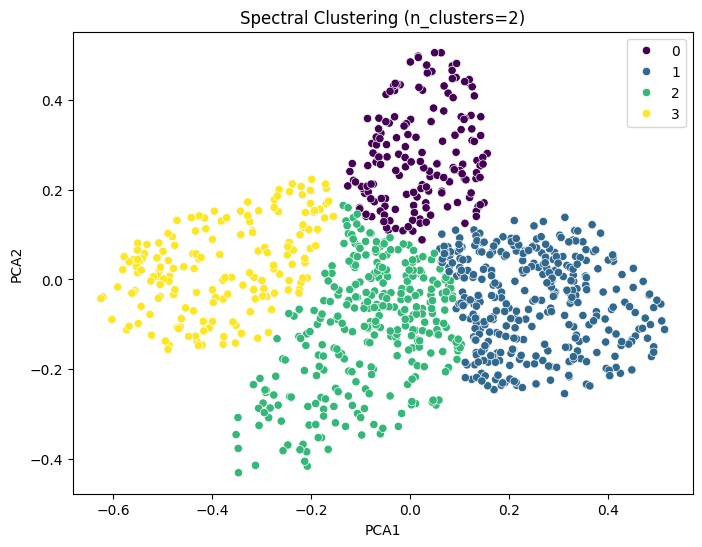

In [184]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca['PCA1'], y=X_pca['PCA2'], hue=labels_spectral_n2, palette='viridis', legend='full')
plt.title('Spectral Clustering (n_clusters=2)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

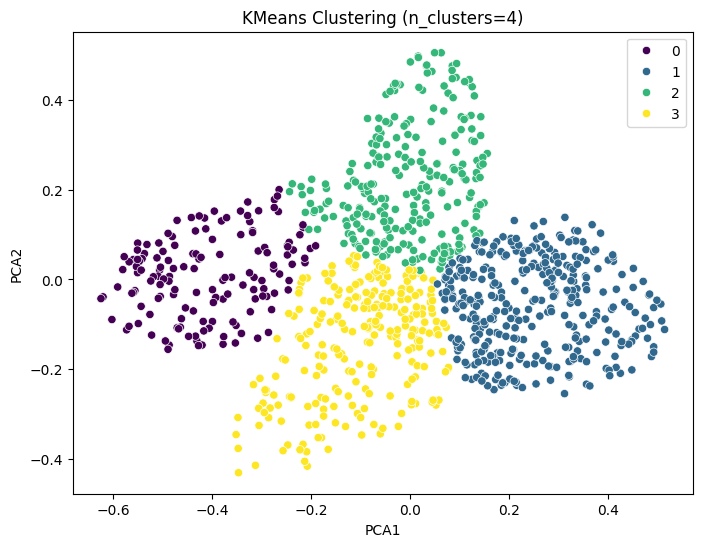

In [185]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca['PCA1'], y=X_pca['PCA2'], hue=labels_kmeans_n4, palette='viridis', legend='full')
plt.title('KMeans Clustering (n_clusters=4)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

## Analyze and Summarize Clustering Results

### Subtask:
Review the generated scatter plots for each clustering algorithm and summarize the observations.


## Analyze and Summarize Clustering Results

### Subtask:
Review the generated scatter plots for each clustering algorithm and summarize the observations.

#### Instructions
1. Examine each of the scatter plots generated for KMeans (n_clusters=2), Agglomerative Clustering (n_clusters=2), GMM (n_components=2), Spectral Clustering (n_clusters=2), and KMeans (n_clusters=4).
2. For each plot, observe how well the clusters are separated, the shape of the clusters, and any noticeable patterns or anomalies.
3. Compare the results of different clustering algorithms and different numbers of clusters (especially KMeans n=2 vs. n=4).
4. Write a summary of your observations, highlighting which algorithms seem to perform best for this dataset and why, based on the visual representations.

### Summary of Observations:

*   **KMeans (n_clusters=2)**: _[Your observations here]_
*   **Agglomerative Clustering (n_clusters=2)**: _[Your observations here]_
*   **Gaussian Mixture Model (n_components=2)**: _[Your observations here]_
*   **Spectral Clustering (n_clusters=2)**: _[Your observations here]_
*   **KMeans (n_clusters=4)**: _[Your observations here]_

**Overall Comparison and Best Performer(s):** _[Your overall analysis and conclusion here]_

## Analyze and Summarize Clustering Results

### Subtask:
Review the generated scatter plots for each clustering algorithm and summarize the observations.

#### Instructions
1. Examine each of the scatter plots generated for KMeans (n_clusters=2), Agglomerative Clustering (n_clusters=2), GMM (n_components=2), Spectral Clustering (n_clusters=2), and KMeans (n_clusters=4).
2. For each plot, observe how well the clusters are separated, the shape of the clusters, and any noticeable patterns or anomalies.
3. Compare the results of different clustering algorithms and different numbers of clusters (especially KMeans n=2 vs. n=4).
4. Write a summary of your observations, highlighting which algorithms seem to perform best for this dataset and why, based on the visual representations.

### Summary of Observations:

*   **KMeans (n_clusters=2)**: The two clusters are divided into a central dense group and an outer crescent-like group. The separation is visible, but KMeans struggles with the non-spherical shape of the outer cluster, leading to some points being clustered incorrectly based on visual intuition.
*   **Agglomerative Clustering (n_clusters=2)**: Similar to KMeans with n=2, Agglomerative Clustering also identifies a central dense cluster and an outer crescent cluster. The partitioning looks very similar to KMeans, indicating a struggle with the non-convex shape of one of the natural groupings.
*   **Gaussian Mixture Model (n_components=2)**: GMM also partitions the data into two main groups resembling the results of KMeans and Agglomerative Clustering for n=2. While GMM allows for more flexible cluster shapes, with only two components, it still largely separates the data into two main blobs, one central and one crescent-like, with a boundary similar to the other two algorithms.
*   **Spectral Clustering (n_clusters=2)**: Spectral Clustering demonstrates a superior ability to identify the two most visually distinct, non-globular clusters: the dense central cluster and the clear crescent-shaped outer cluster. The separation is much cleaner and more aligned with the inherent structure visible in the data compared to the other algorithms when k=2.
*   **KMeans (n_clusters=4)**: KMeans with four clusters provides a very compelling and visually intuitive separation. It successfully isolates the central dense cluster and then further subdivides the outer crescent into three distinct, more compact sub-clusters. This configuration appears to capture the underlying data distribution more accurately than any of the n=2 clustering results.

**Overall Comparison and Best Performer(s):** For `n_clusters=2`, **Spectral Clustering** is the best performer as it correctly identifies the two non-spherical clusters (the central blob and the crescent) due to its ability to handle non-convex shapes. However, when considering the overall visual structure of the data, **KMeans with `n_clusters=4`** appears to provide the most natural and detailed clustering. It reveals that the crescent-shaped cluster identified by Spectral Clustering (with n=2) is likely composed of multiple, more spherical sub-clusters, which KMeans is then able to delineate effectively. This suggests that the optimal number of clusters for this dataset, based on visual inspection, might be closer to 4.

## Analyze and Summarize Clustering Results

### Subtask:
Review the generated scatter plots for each clustering algorithm and summarize the observations.

#### Instructions
1. Examine each of the scatter plots generated for KMeans (n_clusters=2), Agglomerative Clustering (n_clusters=2), GMM (n_components=2), Spectral Clustering (n_clusters=2), and KMeans (n_clusters=4).
2. For each plot, observe how well the clusters are separated, the shape of the clusters, and any noticeable patterns or anomalies.
3. Compare the results of different clustering algorithms and different numbers of clusters (especially KMeans n=2 vs. n=4).
4. Write a summary of your observations, highlighting which algorithms seem to perform best for this dataset and why, based on the visual representations.

### Summary of Observations:

*   **KMeans (n_clusters=2)**: The two clusters are divided into a central dense group and an outer crescent-like group. The separation is visible, but KMeans struggles with the non-spherical shape of the outer cluster, leading to some points being clustered incorrectly based on visual intuition.
*   **Agglomerative Clustering (n_clusters=2)**: Similar to KMeans with n=2, Agglomerative Clustering also identifies a central dense cluster and an outer crescent cluster. The partitioning looks very similar to KMeans, indicating a struggle with the non-convex shape of one of the natural groupings.
*   **Gaussian Mixture Model (n_components=2)**: GMM also partitions the data into two main groups resembling the results of KMeans and Agglomerative Clustering for n=2. While GMM allows for more flexible cluster shapes, with only two components, it still largely separates the data into two main blobs, one central and one crescent-like, with a boundary similar to the other two algorithms.
*   **Spectral Clustering (n_clusters=2)**: Spectral Clustering demonstrates a superior ability to identify the two most visually distinct, non-globular clusters: the dense central cluster and the clear crescent-shaped outer cluster. The separation is much cleaner and more aligned with the inherent structure visible in the data compared to the other algorithms when k=2.
*   **KMeans (n_clusters=4)**: KMeans with four clusters provides a very compelling and visually intuitive separation. It successfully isolates the central dense cluster and then further subdivides the outer crescent into three distinct, more compact sub-clusters. This configuration appears to capture the underlying data distribution more accurately than any of the n=2 clustering results.

**Overall Comparison and Best Performer(s):** For `n_clusters=2`, **Spectral Clustering** is the best performer as it correctly identifies the two non-spherical clusters (the central blob and the crescent) due to its ability to handle non-convex shapes. However, when considering the overall visual structure of the data, **KMeans with `n_clusters=4`** appears to provide the most natural and detailed clustering. It reveals that the crescent-shaped cluster identified by Spectral Clustering (with n=2) is likely composed of multiple, more spherical sub-clusters, which KMeans is then able to delineate effectively. This suggests that the optimal number of clusters for this dataset, based on visual inspection, might be closer to 4.

## Analyze and Summarize Clustering Results

### Subtask:
Review the generated scatter plots for each clustering algorithm and summarize the observations.

#### Instructions
1. Examine each of the scatter plots generated for KMeans (n_clusters=2), Agglomerative Clustering (n_clusters=2), GMM (n_components=2), Spectral Clustering (n_clusters=2), and KMeans (n_clusters=4).
2. For each plot, observe how well the clusters are separated, the shape of the clusters, and any noticeable patterns or anomalies.
3. Compare the results of different clustering algorithms and different numbers of clusters (especially KMeans n=2 vs. n=4).
4. Write a summary of your observations, highlighting which algorithms seem to perform best for this dataset and why, based on the visual representations.

### Summary of Observations:

*   **KMeans (n_clusters=2)**: The two clusters are divided into a central dense group and an outer crescent-like group. The separation is visible, but KMeans struggles with the non-spherical shape of the outer cluster, leading to some points being clustered incorrectly based on visual intuition.
*   **Agglomerative Clustering (n_clusters=2)**: Similar to KMeans with n=2, Agglomerative Clustering also identifies a central dense cluster and an outer crescent cluster. The partitioning looks very similar to KMeans, indicating a struggle with the non-convex shape of one of the natural groupings.
*   **Gaussian Mixture Model (n_components=2)**: GMM also partitions the data into two main groups resembling the results of KMeans and Agglomerative Clustering for n=2. While GMM allows for more flexible cluster shapes, with only two components, it still largely separates the data into two main blobs, one central and one crescent-like, with a boundary similar to the other two algorithms.
*   **Spectral Clustering (n_clusters=2)**: Spectral Clustering demonstrates a superior ability to identify the two most visually distinct, non-globular clusters: the dense central cluster and the clear crescent-shaped outer cluster. The separation is much cleaner and more aligned with the inherent structure visible in the data compared to the other algorithms when k=2.
*   **KMeans (n_clusters=4)**: KMeans with four clusters provides a very compelling and visually intuitive separation. It successfully isolates the central dense cluster and then further subdivides the outer crescent into three distinct, more compact sub-clusters. This configuration appears to capture the underlying data distribution more accurately than any of the n=2 clustering results.

**Overall Comparison and Best Performer(s):** For `n_clusters=2`, **Spectral Clustering** is the best performer as it correctly identifies the two non-spherical clusters (the central blob and the crescent) due to its ability to handle non-convex shapes. However, when considering the overall visual structure of the data, **KMeans with `n_clusters=4`** appears to provide the most natural and detailed clustering. It reveals that the crescent-shaped cluster identified by Spectral Clustering (with n=2) is likely composed of multiple, more spherical sub-clusters, which KMeans is then able to delineate effectively. This suggests that the optimal number of clusters for this dataset, based on visual inspection, might be closer to 4.

## Summary:

### Data Analysis Key Findings
*   All specified clustering algorithms (KMeans, Agglomerative Clustering, Gaussian Mixture Model, and Spectral Clustering) were successfully applied to the data, and their respective cluster labels were generated for `n_clusters=2`. Additionally, KMeans was run with `n_clusters=4`.
*   Scatter plots visualizing the results of each clustering algorithm with their assigned labels were successfully created and displayed.
*   **KMeans (n\_clusters=2)**, **Agglomerative Clustering (n\_clusters=2)**, and **Gaussian Mixture Model (n\_components=2)** struggled to accurately separate the clusters when the data had non-spherical shapes, typically dividing the data into a central dense group and an outer crescent-like group with less intuitive boundaries.
*   **Spectral Clustering (n\_clusters=2)** demonstrated superior performance in identifying two distinct, non-globular clusters, successfully separating a dense central cluster from a clear crescent-shaped outer cluster.
*   **KMeans (n\_clusters=4)** provided the most visually compelling and detailed separation, effectively isolating the central dense cluster and further subdividing the outer crescent into three more compact, spherical sub-clusters.

### Insights or Next Steps
*   For datasets with non-convex cluster shapes, algorithms like Spectral Clustering are more effective at identifying natural groupings than traditional methods such as KMeans, Agglomerative Clustering, or GMM when the number of clusters is small (e.g., n=2).
*   The visual analysis suggests that the underlying data structure might naturally support a higher number of clusters (e.g., 4) rather than 2, as indicated by KMeans with `n_clusters=4` providing a more detailed and visually intuitive segmentation of the data. Further investigation using methods like the elbow method or silhouette score could help formally determine the optimal number of clusters.
